## Imports do dataset e bibliotecas

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv(path + "/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Removendo duplicatas e checando por valores ausentes

In [4]:
# Removendo duplicatas
df.drop_duplicates(keep = 'first', inplace = True)

# Sem valores ausentes
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Tratando outliers

<Axes: ylabel='charges'>

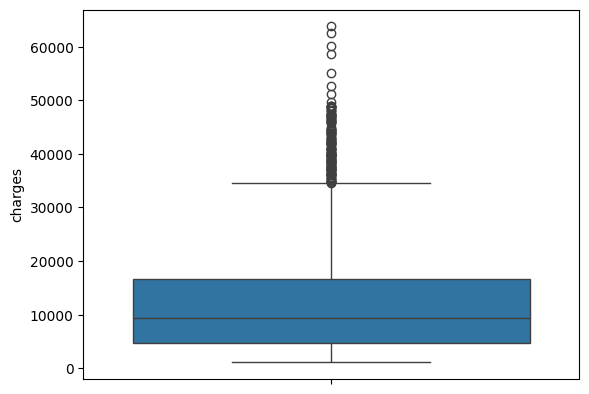

In [5]:
sns.boxplot(df['charges'])

In [6]:
q1 = df["charges"].quantile(0.25)
q3 = df["charges"].quantile(0.75)
iqr = q3 - q1

li = q1 - 1.5 * iqr
ls = q3 + 1.5 * iqr

outliers = df[(df["charges"] >= ls) | (df["charges"] <= li)]

print(f"outliers:{len(outliers)}")
print(f"tamanho total:{len(df)}")

# Porcentagem muito alta, pelo gráfico poucos desses valores devem ser outliers
print(f"porcentagem: {100 * len(outliers)/len(df)}%")

outliers_acima = df[(df["charges"] >= ls)]

print(f"outliers acima:{len(outliers_acima)}")

df5 = df[(df["charges"] >= 50000)]
print(f"maior que 50000:{len(df5)}")

outliers:139
tamanho total:1337
porcentagem: 10.396409872849663%
outliers acima:139
maior que 50000:7


In [7]:
# Decidiu-se por remover apenas os valores maiores que 50000
df.drop(df5.index, inplace = True)

## Tratamentos finais

In [8]:
# One hot encoding
df = pd.get_dummies(df, columns = ['sex', 'smoker', 'region'])
df.head(10)

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False
5,31,25.740,0,3756.62160,True,False,True,False,False,False,True,False
6,46,33.440,1,8240.58960,True,False,True,False,False,False,True,False
7,37,27.740,3,7281.50560,True,False,True,False,False,True,False,False
8,37,29.830,2,6406.41070,False,True,True,False,True,False,False,False
9,60,25.840,0,28923.13692,True,False,True,False,False,True,False,False


In [9]:
# Normalização
df['age'] = (df['age'] - df['age'].min()) / (df['age'].max() - df['age'].min())
df['bmi'] = (df['bmi'] - df['bmi'].min()) / (df['bmi'].max() - df['bmi'].min())
df['children'] = (df['children'] - df['children'].min()) / (df['children'].max() - df['children'].min())

## Aplicando regressão linear

In [12]:
x = df.drop('charges', axis = 1)
y = df['charges']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.75, random_state = 42)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)

print(f'MSE: {mse}')

r2_score = r2_score(y_test, y_pred)

print(f'R2 Score: {r2_score}')

MSE: 33941605.94459926
R2 Score: 0.7402490043111913
